In [38]:
from pathlib import Path
from matplotlib import rc
import matplotlib.pyplot as plt
import xarray as xr 

In [39]:
def set_rc_params(fontsize=None):
    '''
    Set figure parameters
    '''

    if fontsize is None:
        fontsize = 16
    else:
        fontsize = int(fontsize)

    rc('font', **{'family': 'serif'})
    rc('text', usetex=True)

    plt.rcParams.update({'axes.linewidth': 1.3})
    plt.rcParams.update({'xtick.labelsize': fontsize})
    plt.rcParams.update({'ytick.labelsize': fontsize})
    plt.rcParams.update({'xtick.major.size': 8})
    plt.rcParams.update({'xtick.major.width': 1.3})
    plt.rcParams.update({'xtick.minor.visible': True})
    plt.rcParams.update({'xtick.minor.width': 1.})
    plt.rcParams.update({'xtick.minor.size': 6})
    plt.rcParams.update({'xtick.direction': 'out'})
    plt.rcParams.update({'ytick.major.width': 1.3})
    plt.rcParams.update({'ytick.major.size': 8})
    plt.rcParams.update({'ytick.minor.visible': True})
    plt.rcParams.update({'ytick.minor.width': 1.})
    plt.rcParams.update({'ytick.minor.size': 6})
    plt.rcParams.update({'ytick.direction': 'out'})
    plt.rcParams.update({'axes.labelsize': fontsize})
    plt.rcParams.update({'axes.titlesize': fontsize})
    plt.rcParams.update({'legend.fontsize': int(fontsize-2)})
    plt.rcParams['text.usetex'] = True
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'


set_rc_params(15)

In [40]:
base_dir = Path("data/weatherbench")

models = [
    "egnn", "eman", "gcn", "gemcnn",
    "hermes", "mpnn", "transformer", "uni"
]

geopotential_500 = {}
temperature_860 = {}

for model in models:
    model_dir = base_dir / model

    geopotential_500[model] = xr.open_dataset(
        model_dir / "deterministic_geopotential_500.nc"
    )

    temperature_860[model] = xr.open_dataset(
        model_dir / "deterministic_temperature_850.nc"
    )


### Converting to Numpy things

In [41]:
import numpy as np

example_ds = geopotential_500[models[0]]

lead_time = example_ds["lead_time"].values
lead_time_days = lead_time / (24 * 3600 * 1e9)  

In [42]:
z500_mse = {}

for model in models:
    ds = geopotential_500[model]

    z500_mse[model] = np.sqrt((
        ds["geopotential"]
        .sel(metric="mse")
        .isel(level=0)
        .values   # → numpy array, shape (lead_time,)
    )) 

In [43]:
z500_acc = {}

for model in models:
    ds = geopotential_500[model]

    z500_acc[model] = (
        ds["geopotential"]
        .sel(metric="acc")
        .isel(level=0)
        .values
    )


In [44]:
import matplotlib.pyplot as plt
import numpy as np

set_rc_params(30)

egnn_rmse = np.load("data/weatherbench/egnn/geopotential_rmse_500.npy")
eman_rmse = np.load("data/weatherbench/eman/geopotential_rmse_500.npy")
gcn_rmse = np.load("data/weatherbench/gcn/geopotential_rmse_500.npy")
gem_rmse = np.load("data/weatherbench/gemcnn/geopotential_rmse_500.npy")
hermes_rmse = np.load("data/weatherbench/hermes/geopotential_rmse_500.npy")
mpnn_rmse = np.load("data/weatherbench/mpnn/geopotential_rmse_500.npy")
transformer_rmse = np.load("data/weatherbench/transformer/geopotential_rmse_500.npy")
uni_rmse = np.load("data/weatherbench/uni/geopotential_rmse_500.npy")

egnn_acc = np.load("data/weatherbench/egnn/geopotential_acc_500.npy")
eman_acc = np.load("data/weatherbench/eman/geopotential_acc_500.npy")
gcn_acc = np.load("data/weatherbench/gcn/geopotential_acc_500.npy")
gem_acc = np.load("data/weatherbench/gemcnn/geopotential_acc_500.npy")
hermes_acc = np.load("data/weatherbench/hermes/geopotential_acc_500.npy")
mpnn_acc = np.load("data/weatherbench/mpnn/geopotential_acc_500.npy")
transformer_acc = np.load("data/weatherbench/transformer/geopotential_acc_500.npy")
uni_acc = np.load("data/weatherbench/uni/geopotential_acc_500.npy")

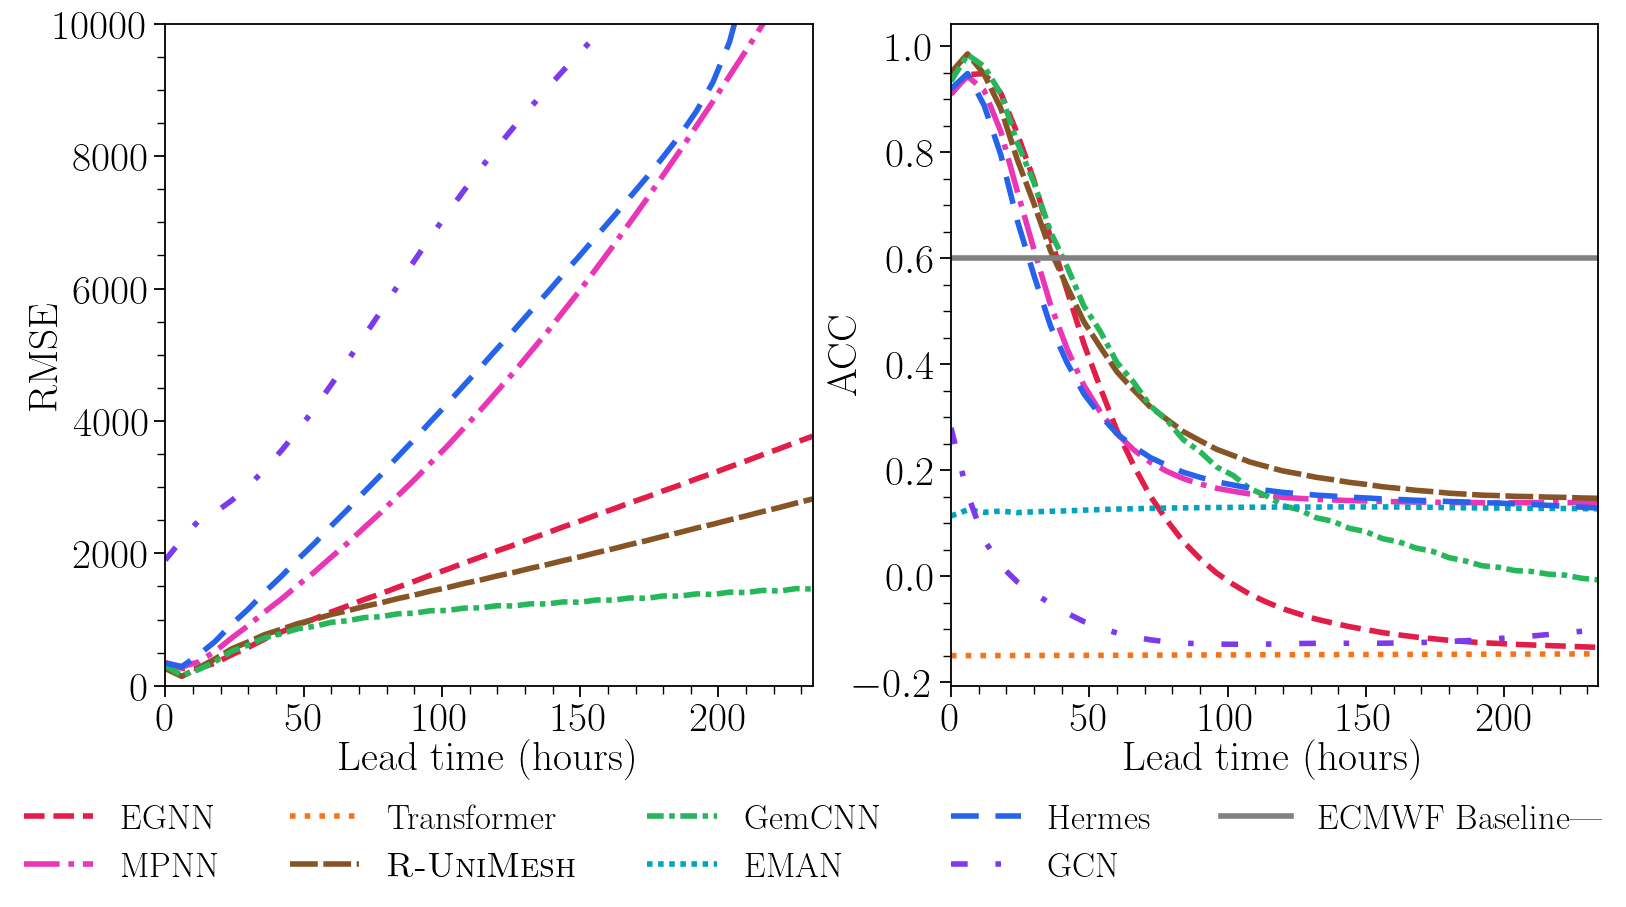

In [45]:
models = ["EGNN", "MPNN", "Transformer", r'$\textsc{R-UniMesh}$',
          "GemCNN", "EMAN", "Hermes", "GCN"]

rmse_arrays = [egnn_rmse, mpnn_rmse, transformer_rmse, uni_rmse,
               gem_rmse, eman_rmse, hermes_rmse, gcn_rmse]

acc_arrays = [egnn_acc, mpnn_acc, transformer_acc, uni_acc,
              gem_acc, eman_acc, hermes_acc, gcn_acc]

colors = [
    "#e11d48",  # vibrant red
    "#e935b6",  # hot pink
    "#f97316",  # vibrant orange
    "#865425",  # golden yellow
    "#26b75b",  # vibrant green
    "#00a3c0",  # cyan / light blue
    "#2563eb",  # strong blue
    "#7c3aed",  # vibrant violet
]

linestyles = [
    "--",               # standard dashed
    "-.",               # dash-dot
    ":",                # dotted
    (0, (5, 1)),        # dense dash
    (0, (3, 1, 1, 1)),  # dash-dot-dot
    (0, (1, 1)),        # fine dotted
    (0, (5, 3)),        # long dash
    (0, (3, 5, 1, 5)),  # complex dash pattern
]

model_styles = {
    model: {"color": colors[i], "linestyle": linestyles[i]}
    for i, model in enumerate(models)
}

timesteps = np.arange(len(egnn_rmse))
hours = timesteps * 6 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# RMSE subplot
for model, rmse_array in zip(models, rmse_arrays):
    style = model_styles[model]
    ax1.plot(hours, rmse_array, color=style["color"],
             linestyle=style["linestyle"], lw=4, label=model)
ax1.set_xlabel("Lead time (hours)", labelpad=-0.5)
ax1.set_ylabel("RMSE", labelpad=-8)
ax1.set_ylim(0, 10000)
ax1.set_xlim(0, 234)

# ACC subplot
for model, acc_array in zip(models, acc_arrays):
    style = model_styles[model]
    ax2.plot(hours, acc_array, color=style["color"],
             linestyle=style["linestyle"], lw=4, label=model)
ax2.set_xlabel("Lead time (hours)", labelpad=-0.5)
ax2.set_ylabel("ACC", labelpad=-8)
ax2.axhline(y=0.6, color='gray', linestyle='-', lw=4, label="ECMWF Baseline|")
ax2.set_xlim(0, 234)

handles, labels = ax2.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    fontsize=25,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15)
)

# Leave room at the bottom for the legend
plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.tight_layout()
plt.savefig("geopotential_metrics_horizontal.png", dpi=300, bbox_inches='tight')

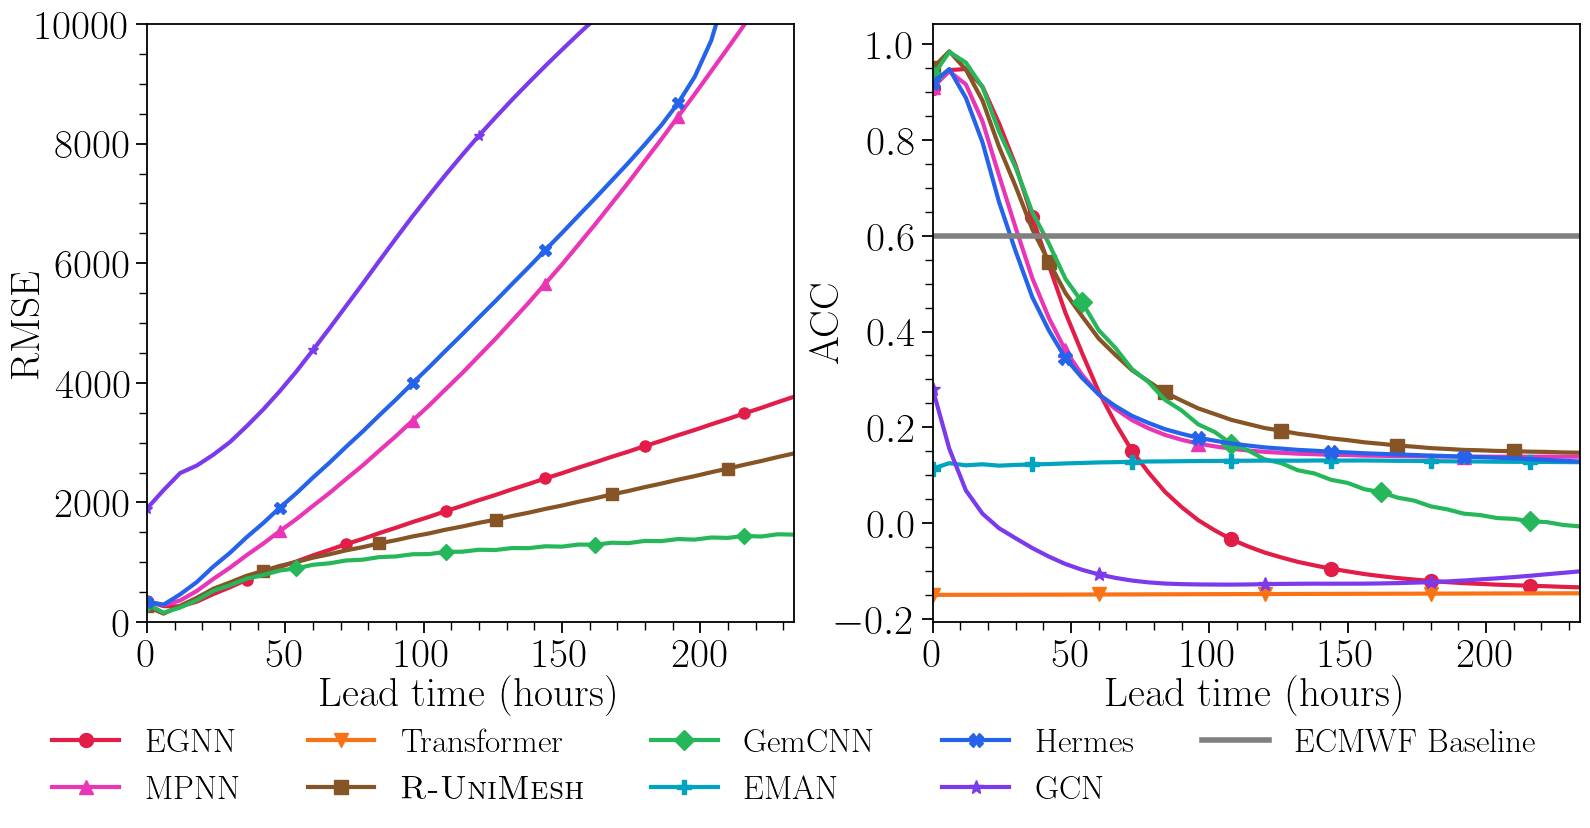

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Assume rmse_arrays, acc_arrays, timesteps, hours are already defined

models = ["EGNN", "MPNN", "Transformer", r'$\textsc{R-UniMesh}$',
          "GemCNN", "EMAN", "Hermes", "GCN"]

colors = [
    "#e11d48",  # vibrant red
    "#e935b6",  # hot pink
    "#f97316",  # vibrant orange
    "#865425",  # golden brown/orange
    "#26b75b",  # vibrant green
    "#00a3c0",  # cyan / light blue
    "#2563eb",  # strong blue
    "#7c3aed",  # vibrant violet
]

markers = ["o", "^", "v", "s", "D", "P", "X", "*"]

# Map each model to color + marker
model_styles = {
    model: {"color": colors[i], "marker": markers[i]}
    for i, model in enumerate(models)
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))


# Different marker intervals for each model
marker_intervals = [6, 8, 10, 7, 9, 6, 8, 10]  # tweak as needed

# --- RMSE subplot ---
for i, (model, rmse_array) in enumerate(zip(models, rmse_arrays)):
    style = model_styles[model]
    ax1.plot(
        hours, rmse_array,
        color=style["color"],
        marker=style["marker"],
        markersize=8,
        markevery=marker_intervals[i],  # sparse and staggered
        linestyle="-",
        lw=3,
        label=model
    )


ax1.set_xlabel("Lead time (hours)", labelpad=-0.5)
ax1.set_ylabel("RMSE", labelpad=-8)
ax1.set_ylim(0, 10000)
ax1.set_xlim(0, 234)

# --- ACC subplot ---
for i, (model, acc_array) in enumerate(zip(models, acc_arrays)):
    style = model_styles[model]
    ax2.plot(
        hours, acc_array,
        color=style["color"],
        marker=style["marker"],
        markersize=10,
        markevery=marker_intervals[i],  # staggered markers
        linestyle="-",
        lw=3,
        label=model
    )

# Baseline ACC line (no markers)
baseline_line = ax2.axhline(y=0.6, color='gray', linestyle='-', lw=4, label="ECMWF Baseline")

ax2.set_xlabel("Lead time (hours)", labelpad=-0.5)
ax2.set_ylabel("ACC", labelpad=-8)
ax2.set_xlim(0, 234)

# --- Legend ---
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine handles, making sure the baseline is included
handles = handles2  # ACC subplot handles already include baseline
labels = labels2

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    fontsize=24,
    frameon=False,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("geopotential_metrics_horizontal.png", dpi=300, bbox_inches='tight')
plt.show()

In [47]:
import matplotlib.pyplot as plt
import numpy as np

set_rc_params(30)

# RMSE arrays
egnn_rmse = np.load("data/weatherbench/egnn/temperature_rmse_850.npy")
eman_rmse = np.load("data/weatherbench/eman/temperature_rmse_850.npy")
gcn_rmse = np.load("data/weatherbench/gcn/temperature_rmse_850.npy")
gem_rmse = np.load("data/weatherbench/gemcnn/temperature_rmse_850.npy")
hermes_rmse = np.load("data/weatherbench/hermes/temperature_rmse_850.npy")
mpnn_rmse = np.load("data/weatherbench/mpnn/temperature_rmse_850.npy")
transformer_rmse = np.load("data/weatherbench/transformer/temperature_rmse_850.npy")
uni_rmse = np.load("data/weatherbench/uni/temperature_rmse_850.npy")

# Accuracy arrays
egnn_acc = np.load("data/weatherbench/egnn/temperature_acc_850.npy")
eman_acc = np.load("data/weatherbench/eman/temperature_acc_850.npy")
gcn_acc = np.load("data/weatherbench/gcn/temperature_acc_850.npy")
gem_acc = np.load("data/weatherbench/gemcnn/temperature_acc_850.npy")
hermes_acc = np.load("data/weatherbench/hermes/temperature_acc_850.npy")
mpnn_acc = np.load("data/weatherbench/mpnn/temperature_acc_850.npy")
transformer_acc = np.load("data/weatherbench/transformer/temperature_acc_850.npy")
uni_acc = np.load("data/weatherbench/uni/temperature_acc_850.npy")


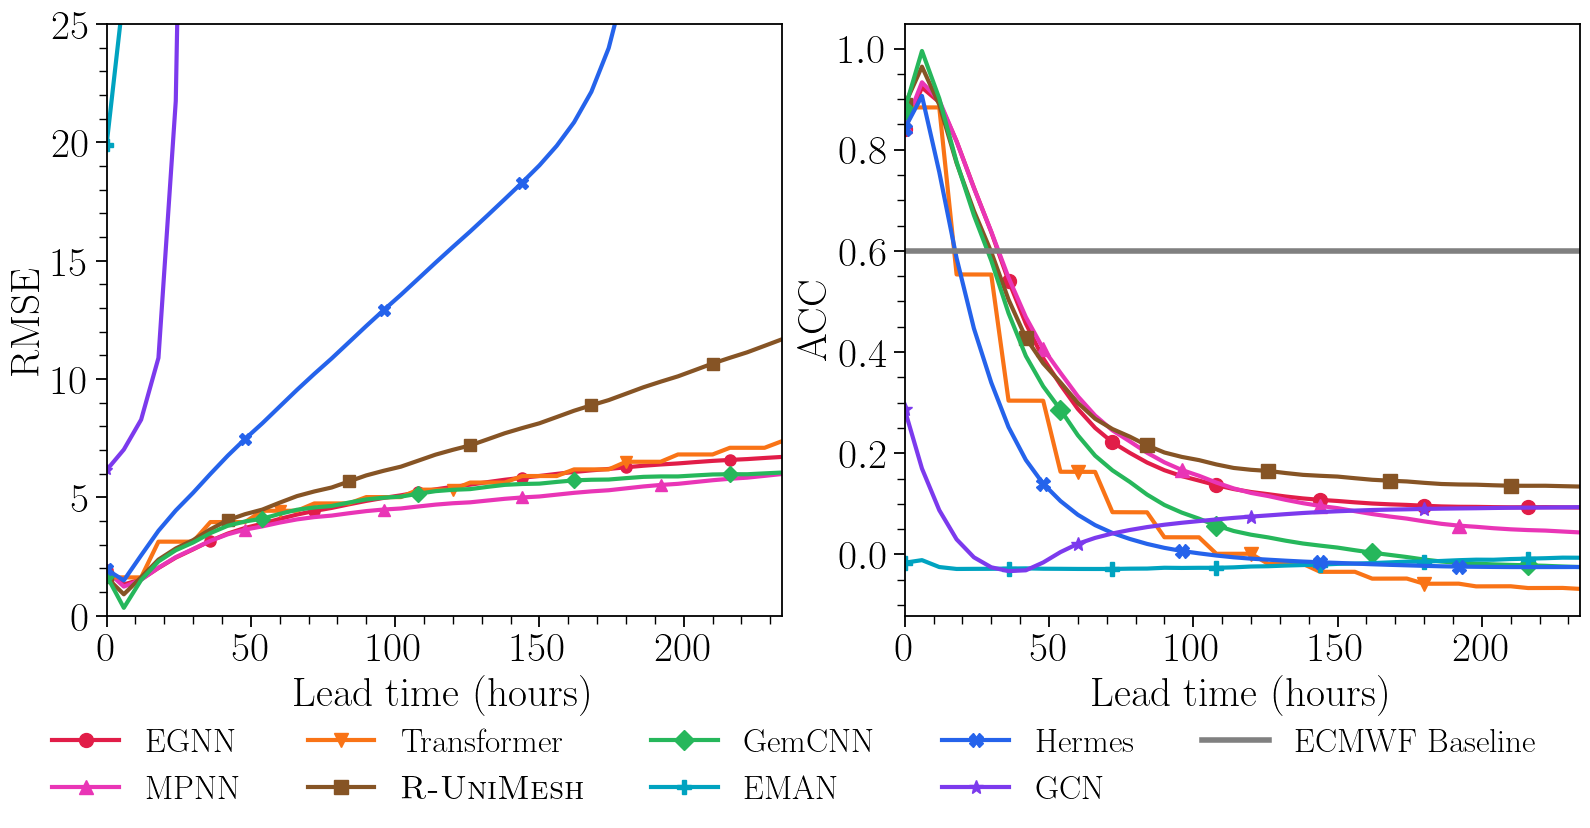

In [48]:
models = ["EGNN", "MPNN", "Transformer", r'$\textsc{R-UniMesh}$',
          "GemCNN", "EMAN", "Hermes", "GCN"]

rmse_arrays = [egnn_rmse, mpnn_rmse, transformer_rmse, uni_rmse,
               gem_rmse, eman_rmse, hermes_rmse, gcn_rmse]

acc_arrays = [egnn_acc, mpnn_acc, transformer_acc, uni_acc,
              gem_acc, eman_acc, hermes_acc, gcn_acc]

timesteps = np.arange(len(egnn_rmse))
hours = timesteps * 6 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))


# Different marker intervals for each model
marker_intervals = [6, 8, 10, 7, 9, 6, 8, 10]  # tweak as needed

# --- RMSE subplot ---
for i, (model, rmse_array) in enumerate(zip(models, rmse_arrays)):
    style = model_styles[model]
    ax1.plot(
        hours, rmse_array,
        color=style["color"],
        marker=style["marker"],
        markersize=8,
        markevery=marker_intervals[i],  # sparse and staggered
        linestyle="-",
        lw=3,
        label=model
    )

    
ax1.set_xlabel("Lead time (hours)", labelpad=4)
ax1.set_ylabel("RMSE", labelpad=4)
ax1.set_ylim(0, 25)
ax1.set_xlim(0, 234)


# --- ACC subplot ---
for i, (model, acc_array) in enumerate(zip(models, acc_arrays)):
    style = model_styles[model]
    ax2.plot(
        hours, acc_array,
        color=style["color"],
        marker=style["marker"],
        markersize=10,
        markevery=marker_intervals[i],  # staggered markers
        linestyle="-",
        lw=3,
        label=model
    )

# Baseline ACC line (no markers)
baseline_line = ax2.axhline(y=0.6, color='gray', linestyle='-', lw=4, label="ECMWF Baseline")

ax2.set_xlabel("Lead time (hours)", labelpad=4)
ax2.set_ylabel("ACC", labelpad=4)
ax2.set_xlim(0, 234)

handles2, labels2 = ax2.get_legend_handles_labels()

# Combine handles, making sure the baseline is included
handles = handles2  # ACC subplot handles already include baseline
labels = labels2

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=5,
    fontsize=24,
    frameon=False,
    bbox_to_anchor=(0.5, -0.05)
)

# Leave room at the bottom for the legend
plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig("temperature_metrics_horizontal.png", dpi=300, bbox_inches='tight')